# Immunophenoscore

Public STAD TPM, first four samples. IPS is a score, not a cell fraction.

Run from the `tutorials` directory in the prepared iobrx environment. Outputs are written to `extension-work/`; the figure uses a display-only feature z-score. No input values are normalized for the analysis unless the visible API parameters request it.

In [1]:
from pathlib import Path
from time import perf_counter
from contextlib import redirect_stdout, redirect_stderr
import io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iobrx
from _common import load, tpm_input, configure, runtime_info
from _extension_figures import plot_result

iobrx.set_threads(2)
slug = '13_ips'
work = Path("extension-work") / slug
work.mkdir(parents=True, exist_ok=True)
print(json.dumps(runtime_info(), indent=2))
groups = None
configure()


{
  "iobrx": "0.3.0",
  "threads": 2,
  "native_available": true,
  "native_reason": null,
  "sorting": "numpy CPU dispatch",
  "requires_avx512": false,
  "bundled_openblas_found": true,
  "versions": {
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.7.2",
    "iobrpy": "0.2.1",
    "gseapy": "1.3.1",
    "matplotlib": "3.11.1"
  }
}


In [2]:
data = tpm_input().iloc[:, :4]

In [3]:
# Capture upstream progress messages; the computation remains the public API call below.
started = perf_counter()
with warnings.catch_warnings(record=True) as diagnostics, redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    result = iobrx.ips(data)
elapsed = perf_counter() - started
for warning in diagnostics:
    print(f"{warning.category.__name__}: {warning.message}")
plot = result.set_index("ID").select_dtypes("number")
tables = result if isinstance(result, dict) else {"result": result}
for name, table in tables.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(work / (name + ".csv"))
plot.to_csv(work / "display_source.csv")
timing = {"analysis": slug, "input_shape": list(data.shape), "seconds": elapsed, "threads": 2, "scope": "one API call; excludes input preparation", "fixture": 'Public STAD TPM, first four samples. IPS is a score, not a cell fraction.'}
Path("results").mkdir(exist_ok=True)
Path("results", slug + "_timing.json").write_text(json.dumps(timing, indent=2) + "\n")
print(json.dumps(timing, indent=2))
display(plot.head())

{
  "analysis": "13_ips",
  "input_shape": [
    48058,
    4
  ],
  "seconds": 0.01595456898212433,
  "threads": 2,
  "scope": "one API call; excludes input preparation",
  "fixture": "Public STAD TPM, first four samples. IPS is a score, not a cell fraction."
}


,MHC_IPS,EC_IPS,SC_IPS,CP_IPS,AZ_IPS,IPS_IPS
ID,,,,,,
TCGA-BR-6455,3.253990,1.194413,-1.231696,-0.426477,2.790230,9
TCGA-BR-7196,3.462623,1.277400,-1.440990,-0.496487,2.802546,9
TCGA-BR-8371,3.015753,0.928050,-0.952901,-0.059541,2.931360,10
TCGA-BR-8380,2.735977,0.931819,-1.129114,-0.008527,2.530155,8


findfont: Failed to find font weight medium, now using 400.


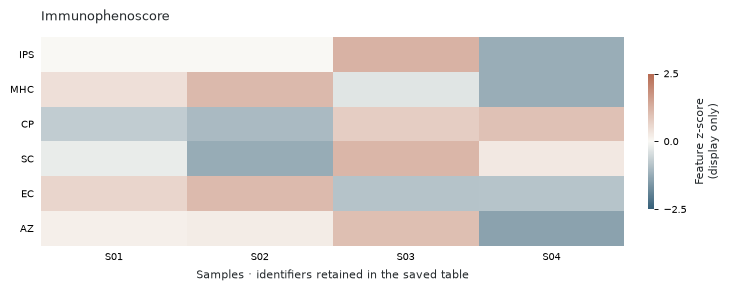

In [4]:
configure(2)
fig = plot_result(plot, 'Immunophenoscore', 2, groups=groups)
for extension in ('png', 'pdf', 'svg'):
    fig.savefig(Path('figures') / (slug + '.' + extension), dpi=200, bbox_inches='tight')
review = Path('review/extensions')
review.mkdir(parents=True, exist_ok=True)
fig.savefig(review / (slug + '-round-2.png'), dpi=120, bbox_inches='tight')
plt.show()

Interpretation: the heatmap highlights relative patterns within each displayed feature. Colors are not cell fractions, statistical significance or cross-feature effect sizes. Full numeric outputs are saved separately. Runtime depends on hardware, input size, parameters and cache state.